# FS→DSA Germany — Exact Baseline Workflow

Purpose: Guarantee that all scenarios start from the same NFPC baseline and that a scenario with zero SPB change reproduces the NFPC DSA exactly, while any SPB change triggers endogenous responses.

Outline:
- Step 1: Exact NFPC replication from Table 17 (levels and growth) — produces `baseline_model`.
- Step 1b: Freeze NFPC baseline counterpart arrays into a reusable `scenario_template` for all subsequent runs.
- Step 2a: Apply MTP SPB path with NFPC anchors (only SPB differs) — endogenous DSA.
- Step 2b: Find binding SPB path (optimal) using the same NFPC anchors.
- Step 2c: Compare results in one chart.
- Step 3: Potential uplift with identical inflation to NFPC and recompute binding SPB.



In [13]:
import sys, warnings, copy
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
warnings.filterwarnings('ignore')

# Resolve project root
cwd = Path.cwd()
project_root = cwd if (cwd / '03_Modell').exists() else cwd.parent
sys.path.extend([
    str((project_root / '03_Modell').parent),
    str(project_root / '03_Modell' / 'EU_DSA' / 'code' / 'classes')
])

from EU_DSA.code.classes import StochasticDsaModel as DSA
from FS_Model.integration import apply_mtp_anchors_to_dsa
from EU_DSA.code.functions import scenario_workflow  # New workflow functions
from FS_Model.data_functions import load_and_process_data
from FS_Model.model_equations import build_model
from FS_Model.scenario_functions import initialize_model, run_scenario_analysis
from FS_Model.integration import apply_mtp_anchors_to_dsa, apply_fs_potential_to_dsa, run_dsa_with_potential_and_spb


START_YEAR, END_YEAR = 2024, 2041
ADJUSTMENT_START_YEAR = 2025
ADJUSTMENT_PERIOD = 7

print('Project root:', project_root)


Project root: c:\Users\dzsve\OneDrive - Dezernat Zukunft e.V\DZ-Schalte - Dokumente\2_Projekte\Fiskalpolitik\F48_EUCAM_DSA_Reformvorschlag


In [14]:
# load data and initialise FS model
DE = load_and_process_data(data_folder='02_Daten', sheet_name='Germany')
FS_model = build_model(include_fiscal=True, include_kg_lag=False)
data_DE = FS_model.insertModelVar(DE)
print('DE data shape:', DE.shape)

DE data shape: (84, 220)


In [15]:
# Initialize template DSA model
dsa_template = DSA(
    country='DEU',
    start_year=START_YEAR,
    end_year=END_YEAR,
    adjustment_period=ADJUSTMENT_PERIOD,
    adjustment_start_year=ADJUSTMENT_START_YEAR,
    fiscal_multiplier_type='ec'
)
dsa_template.project()

a0 = dsa_template.adjustment_start
#a1 = dsa_template.adjustment_end
#closure_end = a1 + dsa_template.fiscal_multiplier_persistence
years = list(range(START_YEAR, END_YEAR + 1))

In [16]:
# NFPC inputs (Table 17) and MTP SPB
rg_pot_nfpc = pd.Series({
    2024: 0.5, 2025: 0.9, 2026: 0.9, 2027: 0.9, 2028: 0.9, 2029: 0.9, 2030: 0.9, 2031: 0.9,
    2032: 0.9, 2033: 0.9, 2034: 0.9, 2035: 0.9, 2036: 0.9, 2037: 0.9, 2038: 0.9, 2039: 0.9, 2040: 0.9, 2041: 0.9
}).reindex(years)

rg_nfpc = pd.Series({
    2024: -0.2, 2025: 0.2, 2026: 0.6, 2027: 1.6, 2028: 1.6, 2029: 1.6, 2030: 0.9, 2031: 0.9,
    2032: 0.9, 2033: 0.9, 2034: 0.9, 2035: 0.9, 2036: 0.9, 2037: 0.9, 2038: 0.9, 2039: 0.9, 2040: 0.9, 2041: 0.9
}).reindex(years)

pi_nfpc = pd.Series({
    2024: 3.1, 2025: 2.7, 2026: 2.6, 2027: 2.6, 2028: 2.6, 2029: 2.5, 2030: 2.5, 2031: 2.4,
    2032: 2.4, 2033: 2.3, 2034: 2.3, 2035: 2.2, 2036: 2.2, 2037: 2.2, 2038: 2.2, 2039: 2.2, 2040: 2.2, 2041: 2.2
}).reindex(years)

spb_target = pd.Series({
    2024: -0.9,     2025: -1.3,     2026: -1.8,     2027: -1.2,     2028: -0.3,     2029: 0.5,     2030: 0.8,     2031: 1.1, 
    2032: 1.1,     2033: 1.1,     2034: 1.1,     2035: 1.1,     2036: 1.1,     2037: 1.1,     2038: 1.1,     2039: 1.1,     2040: 1.1,     2041: 1.1, 
}).reindex(years)

## Step 1 — NFPC replication (Table 17)


In [17]:
# STEP 1: Create NFPC Baseline using new workflow function
print("Step 1: Creating NFPC baseline...")
NFPC = scenario_workflow.create_nfpc_baseline(
    rg=rg_nfpc,
    rg_pot=rg_pot_nfpc,
    pi=pi_nfpc,
    dsa_model=dsa_template,
    spb_baseline=-0.9,
    inplace=False
)
df_NFPC = NFPC.df(all=True)

# Verify NFPC baseline
print("\n=== NFPC Baseline Created ===")
print(f"Output gap baseline in year 2027 (t=0): {NFPC.output_gap_bl[0]:.4f}%")
print(f"Output gap baseline in year 2027 (t=1): {NFPC.output_gap_bl[1]:.4f}%")
print(f"Output gap baseline in year 2027 (t=2): {NFPC.output_gap_bl[2]:.4f}%")
print(f"Output gap baseline in year 2027 (t=3): {NFPC.output_gap_bl[3]:.4f}%")
print(f"Output gap baseline in year 2028 (t=4): {NFPC.output_gap_bl[4]:.4f}%")
print(f"Output gap baseline in year 2029 (t=5): {NFPC.output_gap_bl[5]:.4f}%")


Step 1: Creating NFPC baseline...

=== NFPC Baseline Created ===
Output gap baseline in year 2027 (t=0): -1.3665%
Output gap baseline in year 2027 (t=1): -2.0507%
Output gap baseline in year 2027 (t=2): -2.3420%
Output gap baseline in year 2027 (t=3): -1.5613%
Output gap baseline in year 2028 (t=4): -0.7807%
Output gap baseline in year 2029 (t=5): 0.0000%


## Step 2a — Apply MTP SPB (NFPC anchors; start from `scenario_template`)


In [18]:
## Step 2a — Apply MTP SPB (NFPC anchors) using new workflow function

# Calculate SPB steps from the MTP target path
spb_steps_mtp = np.zeros(ADJUSTMENT_PERIOD)
for tt in range(NFPC.adjustment_start, NFPC.adjustment_end + 1):
    yy = NFPC.start_year + tt
    spb_steps_mtp[tt - NFPC.adjustment_start] = spb_target.loc[yy] - spb_target.loc[yy - 1]

print(f"MTP SPB steps: {spb_steps_mtp}")

# Use new workflow function to create MTP scenario
print("\nCreating MTP scenario with predefined SPB steps...")
scenario_mtp, spb_steps_used, binding_spb = scenario_workflow.create_mtp_scenario(
    baseline_nfpc=NFPC,
    spb_steps_mtp=spb_steps_mtp,
    inplace=False
)

df_sce_mtp = scenario_mtp.df(all=True)
print('Step 2a: MTP SPB scenario created successfully.')


MTP SPB steps: [-0.4 -0.5  0.6  0.9  0.8  0.3  0.3]

Creating MTP scenario with predefined SPB steps...
Step 2a: MTP SPB scenario created successfully.


## Step 2b — Binding SPB path from NFPC anchors


In [19]:
## Step 2b — Binding SPB path from NFPC anchors using new workflow function

# ============================================================================
# EXAMPLE: Using predefined SPB steps for 2025 and 2026
# ============================================================================
# Define SPB steps for the first 2 years (2025 and 2026)
# These steps represent the change in SPB from the previous year
# For example, [-1.0, -1.0] means a 1 percentage point expansion in both years
# The remaining 5 years (2027-2031) will be optimized to meet DSA criteria

# Option: Define predefined steps for backloading (e.g., expansion in early years)
predefined_steps_binding = np.array([-0.4, -0.5])  # -1 pp expansion in 2025 and 2026

print("Finding binding SPB path with predefined steps...")
print(f"Using predefined SPB steps for 2025-2026: {predefined_steps_binding}")
print("Remaining years (2027-2031) will be optimized by find_spb_binding()")

binding_mtp, spb_steps_binding, binding_spb_target = scenario_workflow.create_mtp_scenario(
    baseline_nfpc=NFPC,
    use_find_binding=True,  # Use find_spb_binding method
    predefined_steps=predefined_steps_binding,  # Define steps for 2025 and 2026
    edp=False,
    debt_safeguard=False,  # Germany uses False
    deficit_resilience=False,  # Germany uses False
    inplace=False
)

df_binding_mtp = binding_mtp.df(all=True)

# Show the complete SPB adjustment path
print(f"\n=== Complete SPB Adjustment Path ===")
for i, year in enumerate(range(2025, 2032)):
    if i < len(predefined_steps_binding):
        print(f"  {year}: {spb_steps_binding[i]:.3f} pp (predefined)")
    else:
        print(f"  {year}: {spb_steps_binding[i]:.3f} pp (optimized)")

print(f"\nBinding SPB target (2031): {binding_spb_target:.3f}%")
print(f"Binding SPB steps: {spb_steps_binding}")

# ============================================================================
# Alternative: Without predefined steps (full optimization)
# ============================================================================
# If you don't want to constrain the first years, simply omit predefined_steps:
# binding_mtp, spb_steps_binding, binding_spb_target = scenario_workflow.create_mtp_scenario(
#     baseline_nfpc=NFPC,
#     use_find_binding=True,
#     # predefined_steps=None,  # Not specified - all years optimized
#     edp=True,
#     debt_safeguard=False,
#     deficit_resilience=False,
#     inplace=False
# )


Finding binding SPB path with predefined steps...
Using predefined SPB steps for 2025-2026: [-0.4 -0.5]
Remaining years (2027-2031) will be optimized by find_spb_binding()
Using predefined SPB steps for first 2 years: [-0.4 -0.5]
Upper bound too restrictive, adjusting to [-10, 9.5]
Upper bound too restrictive, adjusting to [-10, 9.0]
Upper bound too restrictive, adjusting to [-10, 8.5]
Upper bound too restrictive, adjusting to [-10, 8.0]
Upper bound too restrictive, adjusting to [-10, 7.5]
Upper bound too restrictive, adjusting to [-10, 7.0]
Upper bound too restrictive, adjusting to [-10, 6.5]
Upper bound too restrictive, adjusting to [-10, 6.0]
SPB optimization succeeded with bounds [-10, 6.0] (adjusted 8 times)

=== Complete SPB Adjustment Path ===
  2025: -0.400 pp (predefined)
  2026: -0.500 pp (predefined)
  2027: 0.558 pp (optimized)
  2028: 0.558 pp (optimized)
  2029: 0.558 pp (optimized)
  2030: 0.558 pp (optimized)
  2031: 0.558 pp (optimized)

Binding SPB target (2031): 0.99

## Step 2c — Comparison chart


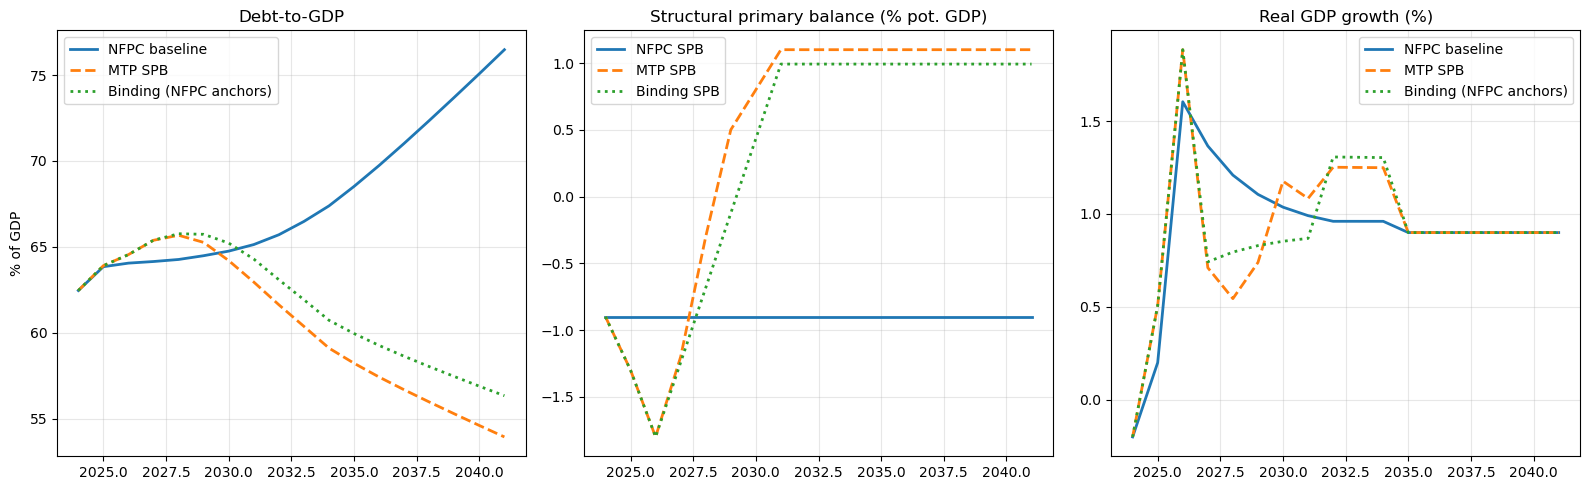

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Debt paths
ax = axes[0]
ax.plot(years, NFPC.d[:len(years)], label='NFPC baseline', lw=2)
ax.plot(years, scenario_mtp.d[:len(years)], '--', label='MTP SPB', lw=2)
ax.plot(years, binding_mtp.d[:len(years)], ':', label='Binding (NFPC anchors)', lw=2)
ax.set_title('Debt-to-GDP'); ax.set_ylabel('% of GDP'); ax.grid(True, alpha=0.3); ax.legend()

# SPB
ax = axes[1]
ax.plot(years, np.full(len(years), -0.9), label='NFPC SPB', lw=2)
ax.plot(years, spb_target.values, '--', label='MTP SPB', lw=2)
ax.plot(years, binding_mtp.spb_bca[:len(years)], ':', label='Binding SPB', lw=2)
ax.set_title('Structural primary balance (% pot. GDP)'); ax.grid(True, alpha=0.3); ax.legend()

# Real growth
ax = axes[2]
ax.plot(years, NFPC.rg[:len(years)], label='NFPC baseline', lw=2)
ax.plot(years, scenario_mtp.rg[:len(years)], '--', label='MTP SPB', lw=2)
ax.plot(years, binding_mtp.rg[:len(years)], ':', label='Binding (NFPC anchors)', lw=2)
ax.set_title('Real GDP growth (%)'); ax.grid(True, alpha=0.3); ax.legend()

plt.tight_layout(); plt.show()


## Step 3 — Potential uplift (optional) with same inflation (NFPC)


In [21]:
#interpret: absolute means the value is added to the baseline value in that year, delta means only the change to the previous year is added
measures = [
     { 'var': 'S_IG_STAR', 'values': [0.420817949, 0.901696279, 0.881651749, 0.87, 0.893377279], 'interpret': 'absolute', 'persist': True, 'persist_mode': 'copy_last' },
]

In [22]:
# Extract paths from the binding DSA model
rg = pd.Series(NFPC.rg, index=years, name='rg')
rg_pot = pd.Series(NFPC.rg_pot, index=years, name='rg_pot')
pi = pd.Series(NFPC.pi, index=years, name='pi')
   
# Create the anchors dictionary
bl_anchors = {
    'rg': rg,
    'rg_pot': rg_pot,
    'pi': pi
}

FS_bl_DE = initialize_model(
    data=data_DE, 
    model_class=FS_model, 
    start=ADJUSTMENT_START_YEAR, 
    end=END_YEAR,
    interest_method='exogenous', 
    baseline_method='DSA_MTP',  
    beta_d_assumption='zero', 
    dsa_model=copy.deepcopy(NFPC),  # Use the NFPC model
    mtp_anchors=bl_anchors,
)


Finding instruments :   0%|          | 0/17

In [23]:
FS_sce_DE_temp = run_scenario_analysis(
    baseline_result=FS_bl_DE, model_class=FS_model,
    scenario_shocks=measures, scenario_name='DE_PREM',
)

,Period 1,Period 2,Period 3,Period 4,Period 5,Period 6,Period 7,Period 8,Period 9,Period 10,Period 11,Period 12,Period 13,Period 14,Period 15,Period 16,Period 17
S_IG_STAR,0.421,0.902,0.882,0.870,0.893,0.893,0.893,0.893,0.893,0.893,0.893,0.893,0.893,0.893,0.893,0.893,0.893


Finding instruments :   0%|          | 0/3

Finding instruments :   0%|          | 0/7

In [24]:
# Step 2: Extract actual investment levels and calculate labor response
actual_investment = FS_sce_DE_temp.loc[2025:2041, 'I_G_REAL'].values  # Actual investment levels
baseline_investment = FS_bl_DE.loc[2025:2041, 'I_G_REAL'].values  # Baseline investment

# Calculate additional investment (in millions)
additional_investment_millions = (actual_investment - baseline_investment) / 1e6  # Convert to millions

# Calculate labor force response (5 workers per million additional investment)
labour_multiplier = 5
working_population = FS_sce_DE_temp.loc[2025:2041, 'WP'].values
lp_changes = additional_investment_millions * labour_multiplier / working_population * 100

print("\n=== Additional Investment (2025–2041) ===")
for year, inv in zip(range(2025, 2042), additional_investment_millions):
    print(f"Year {year}: {inv:,.2f} million EUR")

print("\n=== LP_TREND Changes (Percentage Points, 2025–2041) ===")
for year, lp in zip(range(2025, 2042), lp_changes):
    print(f"Year {year}: {lp:.4f} pp")

# Calculate annual TFP changes based on K_G difference 5 years ago
if 'K_G' in FS_sce_DE_temp.columns and 'K_G' in FS_bl_DE.columns:
    scenario_capital = FS_sce_DE_temp.loc[2025:2041, 'K_G'].values
    baseline_capital = FS_bl_DE.loc[2025:2041, 'K_G'].values
    years = FS_sce_DE_temp.loc[2025:2041].index.tolist()
    print("\n=== Public Capital Stock (K_G) ===")
    print("Scenario:", ", ".join([f"{v:,.0f}" for v in scenario_capital]))
    print("Baseline:", ", ".join([f"{v:,.0f}" for v in baseline_capital]))

    pct_diff_capital = (scenario_capital - baseline_capital) / baseline_capital * 100
    print("\n=== Percentage Difference in K_G (Scenario vs Baseline, %) ===")
    for year, pct in zip(years, pct_diff_capital):
        print(f"Year {year}: {pct:+.3f} %")
    
    # Calculate annual TFP changes: for year t, TFP change = 0.05 * pct_diff_capital[t-5] (in percent)
    # Store as decimal points (e.g., 0.05 percent = 0.0005)
    tfp_changes_decimal = [0.0] * len(pct_diff_capital)
    for i in range(5, len(pct_diff_capital)):
        tfp_changes_decimal[i] = pct_diff_capital[i-5] * 0.05 / 100  # 0.05% per 1% after 5 years

    print("\n=== Annual TFP Changes from K_G Diff 5 Years Ago (as decimal, 2025–2041) ===")
    for year, tfp in zip(years, tfp_changes_decimal):
        print(f"Year {year}: {tfp:+.5f}")
else:
    print("\n[Warning] 'K_G' not found in one of the dataframes. Cannot compute public capital stock difference.")


=== Additional Investment (2025–2041) ===
Year 2025: 15,385.31 million EUR
Year 2026: 33,838.88 million EUR
Year 2027: 33,872.15 million EUR
Year 2028: 34,150.59 million EUR
Year 2029: 35,757.94 million EUR
Year 2030: 36,438.23 million EUR
Year 2031: 37,098.27 million EUR
Year 2032: 37,648.44 million EUR
Year 2033: 38,175.01 million EUR
Year 2034: 38,677.08 million EUR
Year 2035: 39,228.61 million EUR
Year 2036: 39,771.02 million EUR
Year 2037: 40,307.40 million EUR
Year 2038: 40,839.59 million EUR
Year 2039: 41,368.73 million EUR
Year 2040: 41,892.74 million EUR
Year 2041: 42,412.35 million EUR

=== LP_TREND Changes (Percentage Points, 2025–2041) ===
Year 2025: 0.1212 pp
Year 2026: 0.2668 pp
Year 2027: 0.2674 pp
Year 2028: 0.2701 pp
Year 2029: 0.2832 pp
Year 2030: 0.2890 pp
Year 2031: 0.2946 pp
Year 2032: 0.2994 pp
Year 2033: 0.3040 pp
Year 2034: 0.3085 pp
Year 2035: 0.3138 pp
Year 2036: 0.3190 pp
Year 2037: 0.3243 pp
Year 2038: 0.3300 pp
Year 2039: 0.3359 pp
Year 2040: 0.3418 pp
Yea

In [25]:
# Step 3: Run final scenario with both shocks
final_measures = [
    #Measure 1: Fiscal package, assuming that 2029 level is kept constant
    { 'var': 'S_IG_STAR', 'values': [0.420817949, 0.901696279, 0.881651749, 0.87, 0.893377279], 'interpret': 'absolute', 'persist': True, 'persist_mode': 'copy_last' },

    { 'var': 'EPS_LP', 'values': lp_changes, 'interpret': 'delta', 'persist': True, 'persist_mode': 'copy_last' },

    { 'var': 'EPS_SR', 'values': tfp_changes_decimal, 'interpret': 'delta', 'persist': True, 'persist_mode': 'copy_last' },
]

In [26]:
FS_sce_DE = run_scenario_analysis(
    baseline_result=FS_bl_DE, 
    model_class=FS_model,
    scenario_shocks=final_measures, 
    scenario_name='DE_PREM'
)

,Period 1,Period 2,Period 3,Period 4,Period 5,Period 6,Period 7,Period 8,Period 9,Period 10,Period 11,Period 12,Period 13,Period 14,Period 15,Period 16,Period 17
S_IG_STAR,0.421,0.902,0.882,0.870,0.893,0.893,0.893,0.893,0.893,0.893,0.893,0.893,0.893,0.893,0.893,0.893,0.893
EPS_LP,0.121,0.146,0.001,0.003,0.013,0.006,0.006,0.005,0.005,0.005,0.005,0.005,0.005,0.006,0.006,0.006,0.006
EPS_SR,0.000,0.000,0.000,0.000,0.000,0.001,0.001,0.001,0.001,0.001,0.001,0.001,0.001,0.001,0.001,0.001,0.001


Finding instruments :   0%|          | 0/3

Finding instruments :   0%|          | 0/7

In [27]:
# Calculate total growth from 2024 to 2041 for Germany (AT)
start_value = FS_bl_DE.loc[2024, 'Y_STAR']
end_value = FS_sce_DE.loc[2041, 'Y_STAR']
total_growth_factor = end_value / start_value

# Calculate the constant annual growth rate from 2025 to 2041 (17 years)
years_span = 2041 - 2024  # 17 years
constant_growth_rate = (total_growth_factor ** (1/years_span)) - 1

# Create smoothed Y_STAR series with constant growth
FS_sce_DE['Y_STAR_smooth'] = FS_sce_DE['Y_STAR'].copy()
FS_sce_DE.loc[2024, 'Y_STAR_smooth'] = start_value

# Apply constant growth from 2025 onwards
for year in range(2025, 2042):
    FS_sce_DE.loc[year, 'Y_STAR_smooth'] = start_value * ((1 + constant_growth_rate) ** (year - 2024))

# Calculate the smoothed growth rates
FS_sce_DE['Y_STAR_growth_smooth'] = FS_sce_DE['Y_STAR_smooth'].pct_change() * 100

print(f"Total growth factor: {total_growth_factor:.4f}")
print(f"Constant annual growth rate: {constant_growth_rate*100:.2f}%")
print(f"Growth from 2024 to 2041: {(total_growth_factor-1)*100:.2f}%")

Total growth factor: 1.2152
Constant annual growth rate: 1.15%
Growth from 2024 to 2041: 21.52%


In [28]:
## Step 3 — Policy-Responsive Scenario with higher potential growth

rg_pot_policy = FS_sce_DE['Y_STAR_growth_smooth'].reindex(years).fillna(method='ffill').fillna(method='bfill')

binding_PREM, spb_steps_policy, binding_spb_target_policy = scenario_workflow.create_policy_responsive_scenario(
    baseline_nfpc=NFPC,
    rg_pot_policy=rg_pot_policy,
    pi=None,
    use_find_binding=True,
    predefined_steps=predefined_steps_binding,
    edp=False,
    debt_safeguard=False,
    deficit_resilience=False,
    inplace=False
)

df_binding_PREM = binding_PREM.df(all=True)
sce_opt_tgt = float(binding_spb_target_policy)
sce_opt_steps = spb_steps_policy.copy()

print(f"Baseline Binding: {binding_spb_target:.3f}% vs Policy Binding: {binding_spb_target_policy:.3f}%")


Using predefined SPB steps for first 2 years: [-0.4 -0.5]
Upper bound too restrictive, adjusting to [-10, 9.5]
Upper bound too restrictive, adjusting to [-10, 9.0]
Upper bound too restrictive, adjusting to [-10, 8.5]
Upper bound too restrictive, adjusting to [-10, 8.0]
Upper bound too restrictive, adjusting to [-10, 7.5]
Upper bound too restrictive, adjusting to [-10, 7.0]
Upper bound too restrictive, adjusting to [-10, 6.5]
Upper bound too restrictive, adjusting to [-10, 6.0]
SPB optimization succeeded with bounds [-10, 6.0] (adjusted 8 times)
Baseline Binding: 0.992% vs Policy Binding: 0.840%


## 4) Results

In [29]:
# SPB, Debt Ratio, and Potential Output Growth comparison - Baseline vs Scenario for Germany

years_de = range(2024, 2042)  # 2024-2041 for Germany

# Helper function to get EUR values (Germany)
def get_eur_values_de(model, year, var):
    if model.start_year <= year <= model.start_year + len(model.spb_bca) - 1:
        idx = year - model.start_year
        return getattr(model, var)[idx] * model.ngdp[idx] / 100 * 1e9
    return np.nan

# Helper function to get percentage values (Germany)
def get_pct_values_de(model, year, var):
    if hasattr(model, var):
        arr = getattr(model, var)
        if model.start_year <= year <= model.start_year + len(arr) - 1:
            idx = year - model.start_year
            return arr[idx]
    return np.nan

# Create data dictionary for Germany, including debt ratio and potential output growth
results_de = {
    'Year': list(years_de),
    'SPB_Baseline_%': [get_pct_values_de(binding_mtp, y, 'spb_bca') for y in years_de],
    'SPB_Scenario_%': [get_pct_values_de(binding_PREM, y, 'spb_bca') for y in years_de],
    'SPB_Baseline_EUR': [get_eur_values_de(binding_mtp, y, 'spb_bca') for y in years_de],
    'SPB_Scenario_EUR': [get_eur_values_de(binding_PREM, y, 'spb_bca') for y in years_de],
    'Debt_Baseline_%': [get_pct_values_de(binding_mtp, y, 'd') for y in years_de],
    'Debt_Scenario_%': [get_pct_values_de(binding_PREM, y, 'd') for y in years_de],
    'PotOut_Growth_Baseline_%': [get_pct_values_de(binding_mtp, y, 'rg_pot') for y in years_de],
    'PotOut_Growth_Scenario_%': [get_pct_values_de(binding_PREM, y, 'rg_pot') for y in years_de],
}

# Create DataFrame for Germany
comparison_df_de = pd.DataFrame(results_de)

# Calculate differences for Germany
comparison_df_de['SPB_Diff_%'] = comparison_df_de['SPB_Scenario_%'] - comparison_df_de['SPB_Baseline_%']
comparison_df_de['SPB_Diff_EUR'] = comparison_df_de['SPB_Scenario_EUR'] - comparison_df_de['SPB_Baseline_EUR']
comparison_df_de['Debt_Diff_%'] = comparison_df_de['Debt_Scenario_%'] - comparison_df_de['Debt_Baseline_%']
comparison_df_de['PotOut_Growth_Diff_%'] = comparison_df_de['PotOut_Growth_Scenario_%'] - comparison_df_de['PotOut_Growth_Baseline_%']

print("SPB, Debt Ratio, and Potential Output Growth Comparison (Germany):")
# Format EUR columns to show in billions (no scientific notation)
eur_cols_de = ['SPB_Baseline_EUR', 'SPB_Scenario_EUR', 'SPB_Diff_EUR']
comparison_df_display_de = comparison_df_de.copy()
for col in eur_cols_de:
    comparison_df_display_de[col] = comparison_df_display_de[col].apply(lambda x: f"{x:,.0f}" if pd.notnull(x) else "")

display(comparison_df_display_de.round(2))

SPB, Debt Ratio, and Potential Output Growth Comparison (Germany):


,Year,SPB_Baseline_%,SPB_Scenario_%,SPB_Baseline_EUR,SPB_Scenario_EUR,Debt_Baseline_%,Debt_Scenario_%,PotOut_Growth_Baseline_%,PotOut_Growth_Scenario_%,SPB_Diff_%,SPB_Diff_EUR,Debt_Diff_%,PotOut_Growth_Diff_%
0,2024,-0.900,-0.900,"-38,747,340,000","-38,747,340,000",62.460,62.460,0.500,NaN,0.000,0,0.000,NaN
1,2025,-1.300,-1.300,"-57,770,886,295","-57,771,328,565",63.900,64.030,0.900,1.150,0.000,"-442,269",0.120,0.250
2,2026,-1.800,-1.800,"-83,616,775,795","-83,898,251,818",64.550,64.540,0.900,1.150,0.000,"-281,476,023",-0.010,0.250
3,2027,-1.240,-1.270,"-59,612,604,835","-61,486,544,300",65.390,65.250,0.900,1.150,-0.030,"-1,873,939,465",-0.140,0.250
4,2028,-0.680,-0.740,"-33,917,557,049","-37,310,313,569",65.760,65.510,0.900,1.150,-0.060,"-3,392,756,520",-0.250,0.250
5,2029,-0.120,-0.220,"-6,393,696,759","-11,236,615,581",65.730,65.390,0.900,1.150,-0.090,"-4,842,918,821",-0.340,0.250
6,2030,0.430,0.310,"23,017,994,340","16,789,765,684",65.220,64.810,0.900,1.150,-0.120,"-6,228,228,657",-0.400,0.250
7,2031,0.990,0.840,"54,377,284,956","46,839,326,959",64.290,63.850,0.900,1.150,-0.150,"-7,537,957,998",-0.430,0.250
8,2032,0.990,0.840,"56,410,062,697","48,705,817,348",63.090,62.650,0.900,1.150,-0.150,"-7,704,245,349",-0.440,0.250
9,2033,0.990,0.840,"58,460,740,951","50,596,460,836",61.920,61.490,0.900,1.150,-0.150,"-7,864,280,115",-0.430,0.250


In [30]:
# Save the comparison dataframe for Germany
comparison_df_de.to_excel('Germany_Results_v3.xlsx', index=False)
print("DataFrame saved as 'Germany_Results_v3.xlsx'")

DataFrame saved as 'Germany_Results_v3.xlsx'


Test: Linear adjustment path from the very start

In [33]:
# ============================================================================
# Alternative: Without predefined steps (full optimization)
# ============================================================================
# If you don't want to constrain the first years, simply omit predefined_steps:
binding_mtp_test, spb_steps_binding_test, binding_spb_target_test = scenario_workflow.create_mtp_scenario(
    baseline_nfpc=NFPC,
    use_find_binding=True,
    edp=False,
    debt_safeguard=False,
    deficit_resilience=False,
    inplace=False
)



Upper bound too restrictive, adjusting to [-10, 9.5]
Upper bound too restrictive, adjusting to [-10, 9.0]
Upper bound too restrictive, adjusting to [-10, 8.5]
Upper bound too restrictive, adjusting to [-10, 8.0]
Upper bound too restrictive, adjusting to [-10, 7.5]
Upper bound too restrictive, adjusting to [-10, 7.0]
Upper bound too restrictive, adjusting to [-10, 6.5]
Upper bound too restrictive, adjusting to [-10, 6.0]
Upper bound too restrictive, adjusting to [-10, 5.5]
Upper bound too restrictive, adjusting to [-10, 5.0]
SPB optimization succeeded with bounds [-10, 5.0] (adjusted 10 times)


In [34]:
## Step 3 — Policy-Responsive Scenario with higher potential growth

binding_PREM_test, spb_steps_policy_test, binding_spb_target_policy_test = scenario_workflow.create_policy_responsive_scenario(
    baseline_nfpc=NFPC,
    rg_pot_policy=rg_pot_policy,
    pi=None,
    use_find_binding=True,
    edp=False,
    debt_safeguard=False,
    deficit_resilience=False,
    inplace=False
)


sce_opt_tgt_test = float(binding_spb_target_policy_test)
sce_opt_steps_test = spb_steps_policy_test.copy()

print(f"Baseline Binding: {binding_spb_target_test:.3f}% vs Policy Binding: {binding_spb_target_policy_test:.3f}%")


Upper bound too restrictive, adjusting to [-10, 9.5]
Upper bound too restrictive, adjusting to [-10, 9.0]
Upper bound too restrictive, adjusting to [-10, 8.5]
Upper bound too restrictive, adjusting to [-10, 8.0]
Upper bound too restrictive, adjusting to [-10, 7.5]
Upper bound too restrictive, adjusting to [-10, 7.0]
Upper bound too restrictive, adjusting to [-10, 6.5]
Upper bound too restrictive, adjusting to [-10, 6.0]
Upper bound too restrictive, adjusting to [-10, 5.5]
Upper bound too restrictive, adjusting to [-10, 5.0]
SPB optimization succeeded with bounds [-10, 5.0] (adjusted 10 times)
Baseline Binding: 0.708% vs Policy Binding: 0.543%
